Imports

In [14]:
import xarray as xr
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os

Ver contenido de los datasets

In [16]:
data_rh = xr.open_dataset("data/raw/input_rh.nc")["rh"].squeeze()
data_z500 = xr.open_dataset("data/raw/input_z500.nc")["z500"].squeeze()

In [17]:
print(data_rh, data_rh.dims, data_rh.coords, data_rh.attrs, sep="\n\n\n")

<xarray.DataArray 'rh' (time: 8771, lat: 189, lon: 481)> Size: 3GB
[797362839 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0
Attributes:
    code:          157
    table:         128
    cell_methods:  time: mean


('time', 'lat', 'lon')


Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0


{'code': np.int32(157), 'table': np.int32(128), 'cell_methods': 'time: mean'}


In [18]:
print(data_z500, data_z500.dims, data_z500.coords, data_z500.attrs, sep="\n\n\n")

<xarray.DataArray 'z500' (time: 8766, lat: 189, lon: 481)> Size: 3GB
[796908294 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0
Attributes:
    code:          129
    table:         128
    cell_methods:  time: mean


('time', 'lat', 'lon')


Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0


{'code': np.int32(129), 'table': np.int32(128), 'cell_methods': 'time: mean'}


Ver contenido del CSV:

In [19]:
data_csv = pd.read_csv('data/raw/data.csv')
print(data_csv.info(), data_csv, sep="\n\n\n")

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  8760 non-null   int64
 1   time        8760 non-null   str  
 2   hw          8760 non-null   int64
 3   dr          8760 non-null   int64
 4   conc        8760 non-null   int64
dtypes: int64(4), str(1)
memory usage: 504.9 KB
None


      Unnamed: 0                 time  hw  dr  conc
0              0  1993-01-01 11:30:00   0   0     0
1              1  1993-01-02 11:30:00   0   0     0
2              2  1993-01-03 11:30:00   0   0     0
3              3  1993-01-04 11:30:00   0   0     0
4              4  1993-01-05 11:30:00   0   0     0
...          ...                  ...  ..  ..   ...
8755        8755  2016-12-27 11:30:00   1   1     1
8756        8756  2016-12-28 11:30:00   1   1     1
8757        8757  2016-12-29 11:30:00   0   1     0
8758        8758  2016-12-30 11:30:00   0   1     0
8759 

Como podemos observar, hay un desfase entre los datos en bruto:

- RH tiene 8771 valores
- z500 tiene 8766 valores
- El CSV tiene 8760 etiquetas

Esto es una diferencia de $8771 - 8760 = 11$ fechas entre datasets. Hay que arreglar esto; hay que preprocesar.

---

Preprocesado de datos: encontrar las fechas problemáticas entre los datarrays

In [20]:
time_z500_np = data_z500.time.to_numpy()
time_rh_np = data_rh.time.to_numpy()

# setxor1d calcula la diferencia exclusiva entre sets, es decir, en este caso fechas que SOLO existen en UNO de los dos datasets.
setxor1d_resultado = np.setxor1d(time_z500_np, time_rh_np)

if setxor1d_resultado in time_z500_np:
    print("Fechas que aparecen solo en z500:", setxor1d_resultado)
elif setxor1d_resultado in time_rh_np:
    print("Fechas que aparecen solo en rh:", setxor1d_resultado)

# Con unique miramos que fechas están repetidas.
unique_fechas_z500, unique_conteo_z500 = np.unique(time_z500_np, return_counts=True)
fechas_repetidas_z500 = unique_fechas_z500[unique_conteo_z500 > 1]

unique_fechas_rh, unique_conteo_rh = np.unique(time_rh_np, return_counts=True)
fechas_repetidas_rh = unique_fechas_rh[unique_conteo_rh > 1]

print("Fechas repetidas en z500:", fechas_repetidas_z500)
print("Fechas repetidas en rh:", fechas_repetidas_rh)

Fechas que aparecen solo en rh: ['2007-02-24T21:30:00.000000000']
Fechas repetidas en z500: []
Fechas repetidas en rh: ['2007-02-25T11:30:00.000000000' '2007-02-26T11:30:00.000000000'
 '2007-02-27T11:30:00.000000000' '2007-02-28T11:30:00.000000000']


$8771 - 8766 = 5$ 

Hay una diferencia de 5 fechas entre ambos datasets.

Observando los prints, el dataset de humedad relativa (rh) contiene 5 fechas duplicadas:

- 2007-02-24T21:30:00.000000000
- 2007-02-25T11:30:00.000000000 
- 2007-02-26T11:30:00.000000000
- 2007-02-27T11:30:00.000000000
- 2007-02-28T11:30:00.000000000

4 de estas 5 fechas son meros duplicados, con mismo valor para rh y z500. El día 24 de Febrero, sin embargo, la fecha se desvía de lo usual con una hora distinta al resto, y un valor distinto para z500 y rh.

In [21]:
indices_fechas_duplicadas = pd.Series(time_rh_np).duplicated(keep='first').to_numpy()
data_rh = data_rh.isel(time = ~indices_fechas_duplicadas)
data_rh = data_rh.drop_sel(time = setxor1d_resultado)
print("Coinciden fechas: ", np.array_equal(data_rh.time.to_numpy(), data_z500.time.to_numpy()))

Coinciden fechas:  True


En este punto se han eliminado las 5 fechas problemáticas, y el print de este code block nos indica que ambos Datasets son ahora parejos.

Veamos de nuevo el contenido de los datasets para confirmar que los datos estén bien:

In [22]:
print(data_rh, data_rh.dims, data_rh.coords, data_rh.attrs, sep="\n\n\n")

<xarray.DataArray 'rh' (time: 8766, lat: 189, lon: 481)> Size: 3GB
[796908294 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0
Attributes:
    code:          157
    table:         128
    cell_methods:  time: mean


('time', 'lat', 'lon')


Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0


{'code': np.int32(157), 'table': np.int32(128), 'cell_methods': 'time: mean'}


In [23]:
print(data_z500, data_z500.dims, data_z500.coords, data_z500.attrs, sep="\n\n\n")

<xarray.DataArray 'z500' (time: 8766, lat: 189, lon: 481)> Size: 3GB
[796908294 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0
Attributes:
    code:          129
    table:         128
    cell_methods:  time: mean


('time', 'lat', 'lon')


Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0


{'code': np.int32(129), 'table': np.int32(128), 'cell_methods': 'time: mean'}


Como podemos observar por el output, ambos Datasets ya comparten el mismo número de datos (8766 fechas), sin embargo, sigue estando 6 unidades por encima del número de etiquetas (8760) contenidas en el CSV. Veamos por qué:

In [24]:
# Se elimina la columna "unamed", que poco aporta en este caso
data_csv = data_csv.drop(columns=['Unnamed: 0'])

# Las fechas están guardadas en strings planos (consultar prints del code block 24), mientras que los DataSets emplean datetime64.
# Convertimos los strings a datetime64 para ahorraros problemas futuros: 
data_csv['time'] = pd.to_datetime(data_csv['time'])

# Utilizando setxor1d obtenemos las fechas que solo aparecen en uno de los dos sets dados (z500 y el csv), es decir, obtenemos las 6
# fechas sobrantes que el CSV no tiene respecto a los datasets.
diferencia = np.setxor1d(data_z500['time'].values, data_csv['time'].values)
print(diferencia, "\n\nDiferencia de fechas:", len(diferencia))

['1996-02-29T11:30:00.000000000' '2000-02-29T11:30:00.000000000'
 '2004-02-29T11:30:00.000000000' '2008-02-29T11:30:00.000000000'
 '2012-02-29T11:30:00.000000000' '2016-02-29T11:30:00.000000000'] 

Diferencia de fechas: 6


Las 6 fechas que el CSV no tiene son las siguientes:

- 1996-02-29T11:30:00.000000000
- 2000-02-29T11:30:00.000000000
- 2004-02-29T11:30:00.000000000
- 2008-02-29T11:30:00.000000000
- 2012-02-29T11:30:00.000000000
- 2016-02-29T11:30:00.000000000 

Estas fechas se corresponden con los 6 años bisiestos que sucedieron en el rango de fechas que abarcan los datasets.

Procedemos a retirarlas de los datasets:

In [25]:
mascara = np.isin(data_z500['time'].values, data_csv['time'].values)
data_z500 = data_z500.isel(time=mascara)
data_rh = data_rh.isel(time=mascara)

# Comprobamos que los datasets y el csv contienen el mismo número de fechas
print(len(data_z500['time']) == len(data_rh['time']) == len(data_csv))

True


Llegados a este punto, todos los datos de entrada ya están preprocesados y listos para usarse. Los datasets serán combinados y guardados en un único archivo NetCDF llamado "predictoras.nc", y el CSV como "etiquetas.csv".

In [26]:
xr.Dataset({'z500': data_z500, 'rh': data_rh}).to_netcdf('data/preprocessed/predictoras.nc')
data_csv.to_parquet('data/preprocessed/etiquetas.parquet')

Probamos a leer los nuevos archivos y a comprobar que todo está bien:

In [27]:
predictoras = xr.open_dataset('data/preprocessed/predictoras.nc')
print(predictoras, predictoras.dims, predictoras.coords, predictoras.attrs, sep="\n\n\n")

etiquetas = pd.read_parquet('data/preprocessed/etiquetas.parquet')
print(etiquetas.info(), etiquetas, sep="\n\n\n")

<xarray.Dataset> Size: 6GB
Dimensions:  (time: 8760, lat: 189, lon: 481)
Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0
Data variables:
    z500     (time, lat, lon) float32 3GB ...
    rh       (time, lat, lon) float32 3GB ...


FrozenMappingWarningOnValuesAccess({'time': 8760, 'lat': 189, 'lon': 481})


Coordinates:
  * time     (time) datetime64[ns] 70kB 1993-01-01T11:30:00 ... 2016-12-31T11...
  * lat      (lat) float64 2kB 25.0 25.25 25.5 25.75 ... 71.25 71.5 71.75 72.0
  * lon      (lon) float64 4kB -60.0 -59.75 -59.5 -59.25 ... 59.5 59.75 60.0


{}
<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    8760 non-null   datetime64[us]
 1   hw 

---

Ver la media de cada valor durante los 23 años

Z500: 56774.02734375
rh: 34.627288818359375


Text(0.5, 1.0, 'rh (humedad relativa, media 1993-2016)')

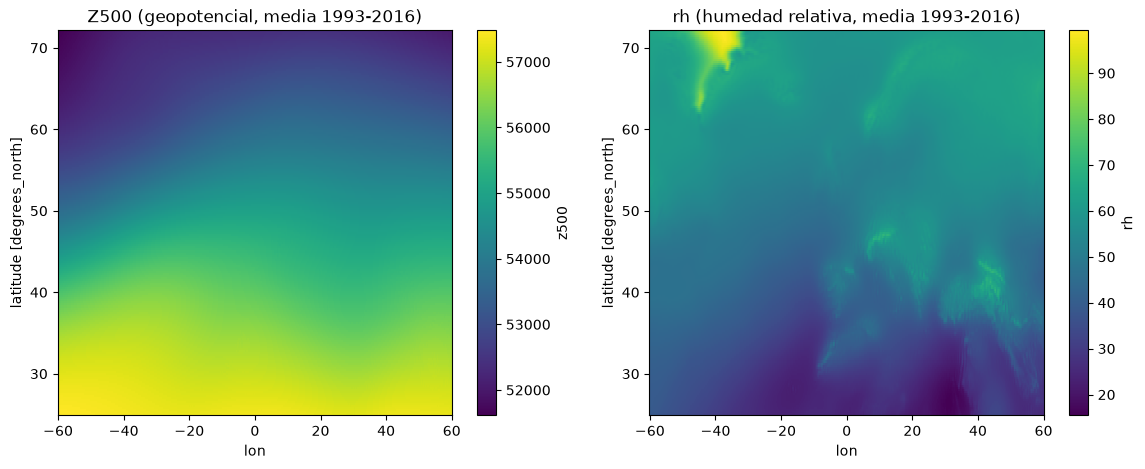

In [31]:
lat = 35.0
lon = -25.75

print("Z500:", predictoras['z500'].sel(lat=lat, lon=lon, method='nearest').mean(dim='time').item())
print("rh:", predictoras['rh'].sel(lat=lat, lon=lon, method='nearest').mean(dim='time').item())

fig, pos = plt.subplots(1, 2, figsize=(14, 5))
predictoras['z500'].mean(dim='time').plot(ax=pos[0])
predictoras['rh'].mean(dim='time').plot(ax=pos[1])
pos[0].set_title("Z500 (geopotencial, media 1993-2016)")
pos[1].set_title("rh (humedad relativa, media 1993-2016)")